In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

### 프로젝트 셋팅

In [3]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = 'model/final_hyperxgboost.dat'

# 교차검증 횟수
cv_count = 10

# Stratified K-Fold 설정 (클래스 비율 유지)
kfold = StratifiedKFold(n_splits=cv_count, shuffle=True, random_state=1)

# 평가 결과를 담을 리스트
f1_score_list = []

# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [65]:
# 데이터 준비
df = pd.read_csv("data/train_ver2_vifed.csv")

# 입력과 결과로 나눈다.
#X = df.drop(columns=['ID', 'Segment', '기준년월'])|
X = df.drop(columns=['ID', 'Segment']) #wide 데이터에는 기준년월 컬럼이 없음.
y = df['Segment']

In [66]:
# 문자열 -> 숫자
encoder1 = LabelEncoder()
encoder1.fit(y)
y2 = encoder1.transform(y)

# 범주형 변수 인코딩
obj_cols = X.select_dtypes(include='object').columns

# 각 컬럼에 대해 Label Encoding 수행
for col in obj_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [67]:
# 입력 데이터 표준화
scaler1 = StandardScaler()
scaler1.fit(X)
X2 = scaler1.transform(X)

In [68]:
# 학습할 데이터를 변수에 담아준다.
train_X = X2
train_y = y2

acc_score_list = []

In [71]:
# 혼동행렬용
# 일정하게 나누기 위한 시드 고정
train_X, test_X, train_y, test_y = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [15]:
# KNN
knn_basic_model = KNeighborsClassifier()

# --- 기존 F1 계산 ---
r1_f1 = cross_val_score(knn_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r1_f1.mean())

# --- 정확도 계산 추가 ---
r1_acc = cross_val_score(knn_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r1_acc.mean())

# 모델 이름 추가
model_name_list.append("KNN Basic")

In [16]:
# Logistic Regression 모델 정의
lr_basic_model = LogisticRegression()

# F1 score (기본은 binary라면 'binary', 다중 클래스라면 'macro'나 'micro' 권장)
r1_f1 = cross_val_score(lr_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r1_f1.mean())

# Accuracy score
r1_acc = cross_val_score(lr_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r1_acc.mean())

# 모델 이름 저장
model_name_list.append("LogisticRegression Basic")

In [17]:
# DecisionTree
tree_basic_model = DecisionTreeClassifier()

# F1 Score (micro 권장)
r1_f1 = cross_val_score(tree_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r1_f1.mean())

# Accuracy
r1_acc = cross_val_score(tree_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r1_acc.mean())

# 모델 이름 저장
model_name_list.append("DecisionTree Basic")


In [18]:
# RandomForest
rf_basic_model = RandomForestClassifier()

# F1 Score (micro)
r2_f1 = cross_val_score(rf_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r2_f1.mean())

# Accuracy
r2_acc = cross_val_score(rf_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r2_acc.mean())

# 모델 이름 저장
model_name_list.append("RandomForest Basic")

In [19]:
# AdaBoost
ada_basic_model = AdaBoostClassifier()

# F1 Score (micro)
r1_f1 = cross_val_score(ada_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r1_f1.mean())

# Accuracy
r1_acc = cross_val_score(ada_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r1_acc.mean())

# 모델 이름 저장
model_name_list.append("AdaBoost Basic")

In [20]:
# GradientBoost
gb_basic_model = GradientBoostingClassifier()

# F1 Score (micro)
r2_f1 = cross_val_score(gb_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r2_f1.mean())

# Accuracy
r2_acc = cross_val_score(gb_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r2_acc.mean())

# 모델 이름 저장
model_name_list.append("GradientBoost Basic")

In [21]:
# LGBM
lgbm_basic_model = LGBMClassifier(verbose=-1)

# F1 Score
r1_f1 = cross_val_score(lgbm_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r1_f1.mean())

# Accuracy
r1_acc = cross_val_score(lgbm_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r1_acc.mean())

# 이름
model_name_list.append("LGBM Basic")

In [75]:
# XGBoost
xgboost_basic_model = XGBClassifier(verbosity=0, use_label_encoder=False)

# F1-score (micro)
r2_f1 = cross_val_score(xgboost_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
f1_score_list.append(r2_f1.mean())

# Accuracy
r2_acc = cross_val_score(xgboost_basic_model, train_X, train_y, scoring='accuracy', cv=kfold)
acc_score_list.append(r2_acc.mean())

model_name_list.append("XGBoost Basic")

# 예측값 (교차검증을 통한)
y_pred = cross_val_predict(xgboost_basic_model, train_X, train_y, cv=kfold)

# 출력
print("XGBoost 결과")
print(f"F1 score (micro): {r2_f1.mean():.4f}")
print(f"Accuracy        : {r2_acc.mean():.4f}")

XGBoost 결과
F1 score (micro): 0.8793
Accuracy        : 0.8793


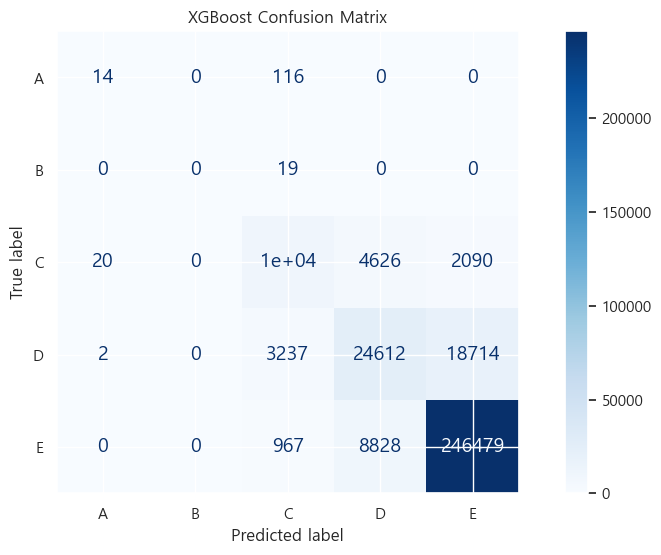

In [76]:
# 혼동행렬
cm = confusion_matrix(train_y, y_pred)
# 원래 클래스 이름 사용
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder1.classes_)
disp.plot(cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

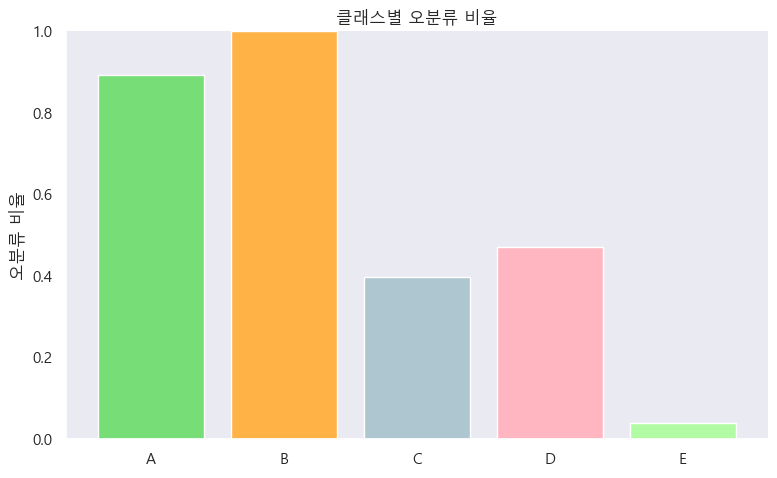

In [77]:
# 클래스별 전체 수 (정답 기준)
class_counts = cm.sum(axis=1)

# 클래스별 정답 수 (대각선)
class_correct = np.diag(cm)

# 클래스별 오분류 수 = 전체 - 정답
class_incorrect = class_counts - class_correct

# 오분류 비율
class_misrate = class_incorrect / class_counts

# 클래스 이름
class_labels = encoder1.classes_

# 색상 맵
color_map = {
    'A': '#77DD77',
    'B': '#FFB347',
    'C': '#AEC6CF',
    'D': '#FFB6C1',
    'E': '#B2FBA5',
}

# 막대 색상 리스트
bar_colors = [color_map[label] for label in class_labels]

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_misrate, color=bar_colors)
plt.ylim(0, 1)
plt.ylabel('오분류 비율')
plt.title('클래스별 오분류 비율')

# 꾸미기
sns.despine()              # 테두리 제거
plt.grid(False)            # 격자선 제거
plt.tight_layout()         # 레이아웃 정리

plt.show()

In [81]:
class_counts = cm.sum(axis=1)
class_correct = np.diag(cm)
class_incorrect = class_counts - class_correct
total_incorrect = class_incorrect.sum()
incorrect_ratio_over_total = class_incorrect / total_incorrect

df_misclassified = pd.DataFrame({
    '클래스': class_labels,
    '오분류 수': class_incorrect,
    '전체 오분류 중 비율': incorrect_ratio_over_total
}).sort_values(by='전체 오분류 중 비율', ascending=False)

print(df_misclassified)

  클래스  오분류 수  전체 오분류 중 비율
3   D  21953     0.568451
4   E   9795     0.253632
2   C   6736     0.174422
0   A    116     0.003004
1   B     19     0.000492


In [23]:
# 결과를 데이터프레임으로 정리
result_df = pd.DataFrame({
    'Model': model_name_list,
    'F1 Score (micro)': f1_score_list,
    'Accuracy': acc_score_list
})

# F1 Score 기준으로 정렬
result_df = result_df.sort_values(by='F1 Score (micro)', ascending=False).reset_index(drop=True)

# 출력
print(result_df)

                      Model  F1 Score (micro)  Accuracy
0                 KNN Basic          0.888090  0.888090
1        RandomForest Basic          0.877740  0.877712
2             XGBoost Basic          0.867625  0.867625
3       GradientBoost Basic          0.863380  0.863399
4                LGBM Basic          0.855104  0.855104
5  LogisticRegression Basic          0.850242  0.850242
6            AdaBoost Basic          0.824384  0.824384
7        DecisionTree Basic          0.818043  0.818158
